# Gaussian summary-dimension diagnostic comparison

This plotting-only notebook produces one 4×4 grid per error metric: rows are `l2`, `mmd`, `density`, and `linf`; columns are assumed models M1–M4. Color denotes summary dimension, circles/squares denote misspecified/well-specified data, and every summary dimension receives its own LOWESS curve. Panel-specific x/y ranges include every finite observation without quantile truncation. Diagnostic x-axes use a symmetric-log scale, and Posterior MMD panels use a y-axis lower limit of -0.5.

The vertical green band is the diagnostic typical set; the horizontal green band is the common calibrated error-acceptance interval.

In [1]:
from IPython.display import Image, display
import pandas as pd

from benchmark.examples.gaussian.analysis.summary_dimension_comparison import (
    DEFAULT_OUTPUT_DIR,
    DIAGNOSTICS,
    ERROR_METRICS,
    run_summary_dimension_comparison,
)

## Plot controls

Set `NORMALIZED=True` to normalize each error and append `normalized` to the single global y-axis label. `X_SYMLOG_LINTHRESH` controls the linear region around zero on every diagnostic x-axis. Each error metric can independently use a `linear` or `symlog` y-axis. The default layout uses all four assumed models.

In [2]:
MODELS = ("m1","m2", "m3","m4")
NORMALIZED = False
LOWESS_FRAC = 1
X_SYMLOG_LINTHRESH = 1.0

YSCALE = {
    "posterior_mmd": "symlog",
    "log10_logml_error": "symlog",
    "pmp_error": "linear",
}
Y_SYMLOG_LINTHRESH = {
    "posterior_mmd": 0.1,
    "log10_logml_error": 1.0,
    "pmp_error": 0.01,
}

In [3]:
comparison = run_summary_dimension_comparison(
    diagnostics=DIAGNOSTICS,
    error_metrics=ERROR_METRICS,
    models=MODELS,
    output_dir=DEFAULT_OUTPUT_DIR,
    normalized=NORMALIZED,
    lowess_frac=LOWESS_FRAC,
    x_symlog_linthresh=X_SYMLOG_LINTHRESH,
    yscale=YSCALE,
    y_symlog_linthresh=Y_SYMLOG_LINTHRESH,
)
pd.DataFrame(
    [
        (error_metric, str(path))
        for error_metric, path in comparison["paths"].items()
    ],
    columns=["error_metric", "path"],
)

,error_metric,path
0,posterior_mmd,/Users/yimingzang/Documents/Project/benchmark2...
1,log10_logml_error,/Users/yimingzang/Documents/Project/benchmark2...
2,pmp_error,/Users/yimingzang/Documents/Project/benchmark2...


## Posterior MMD

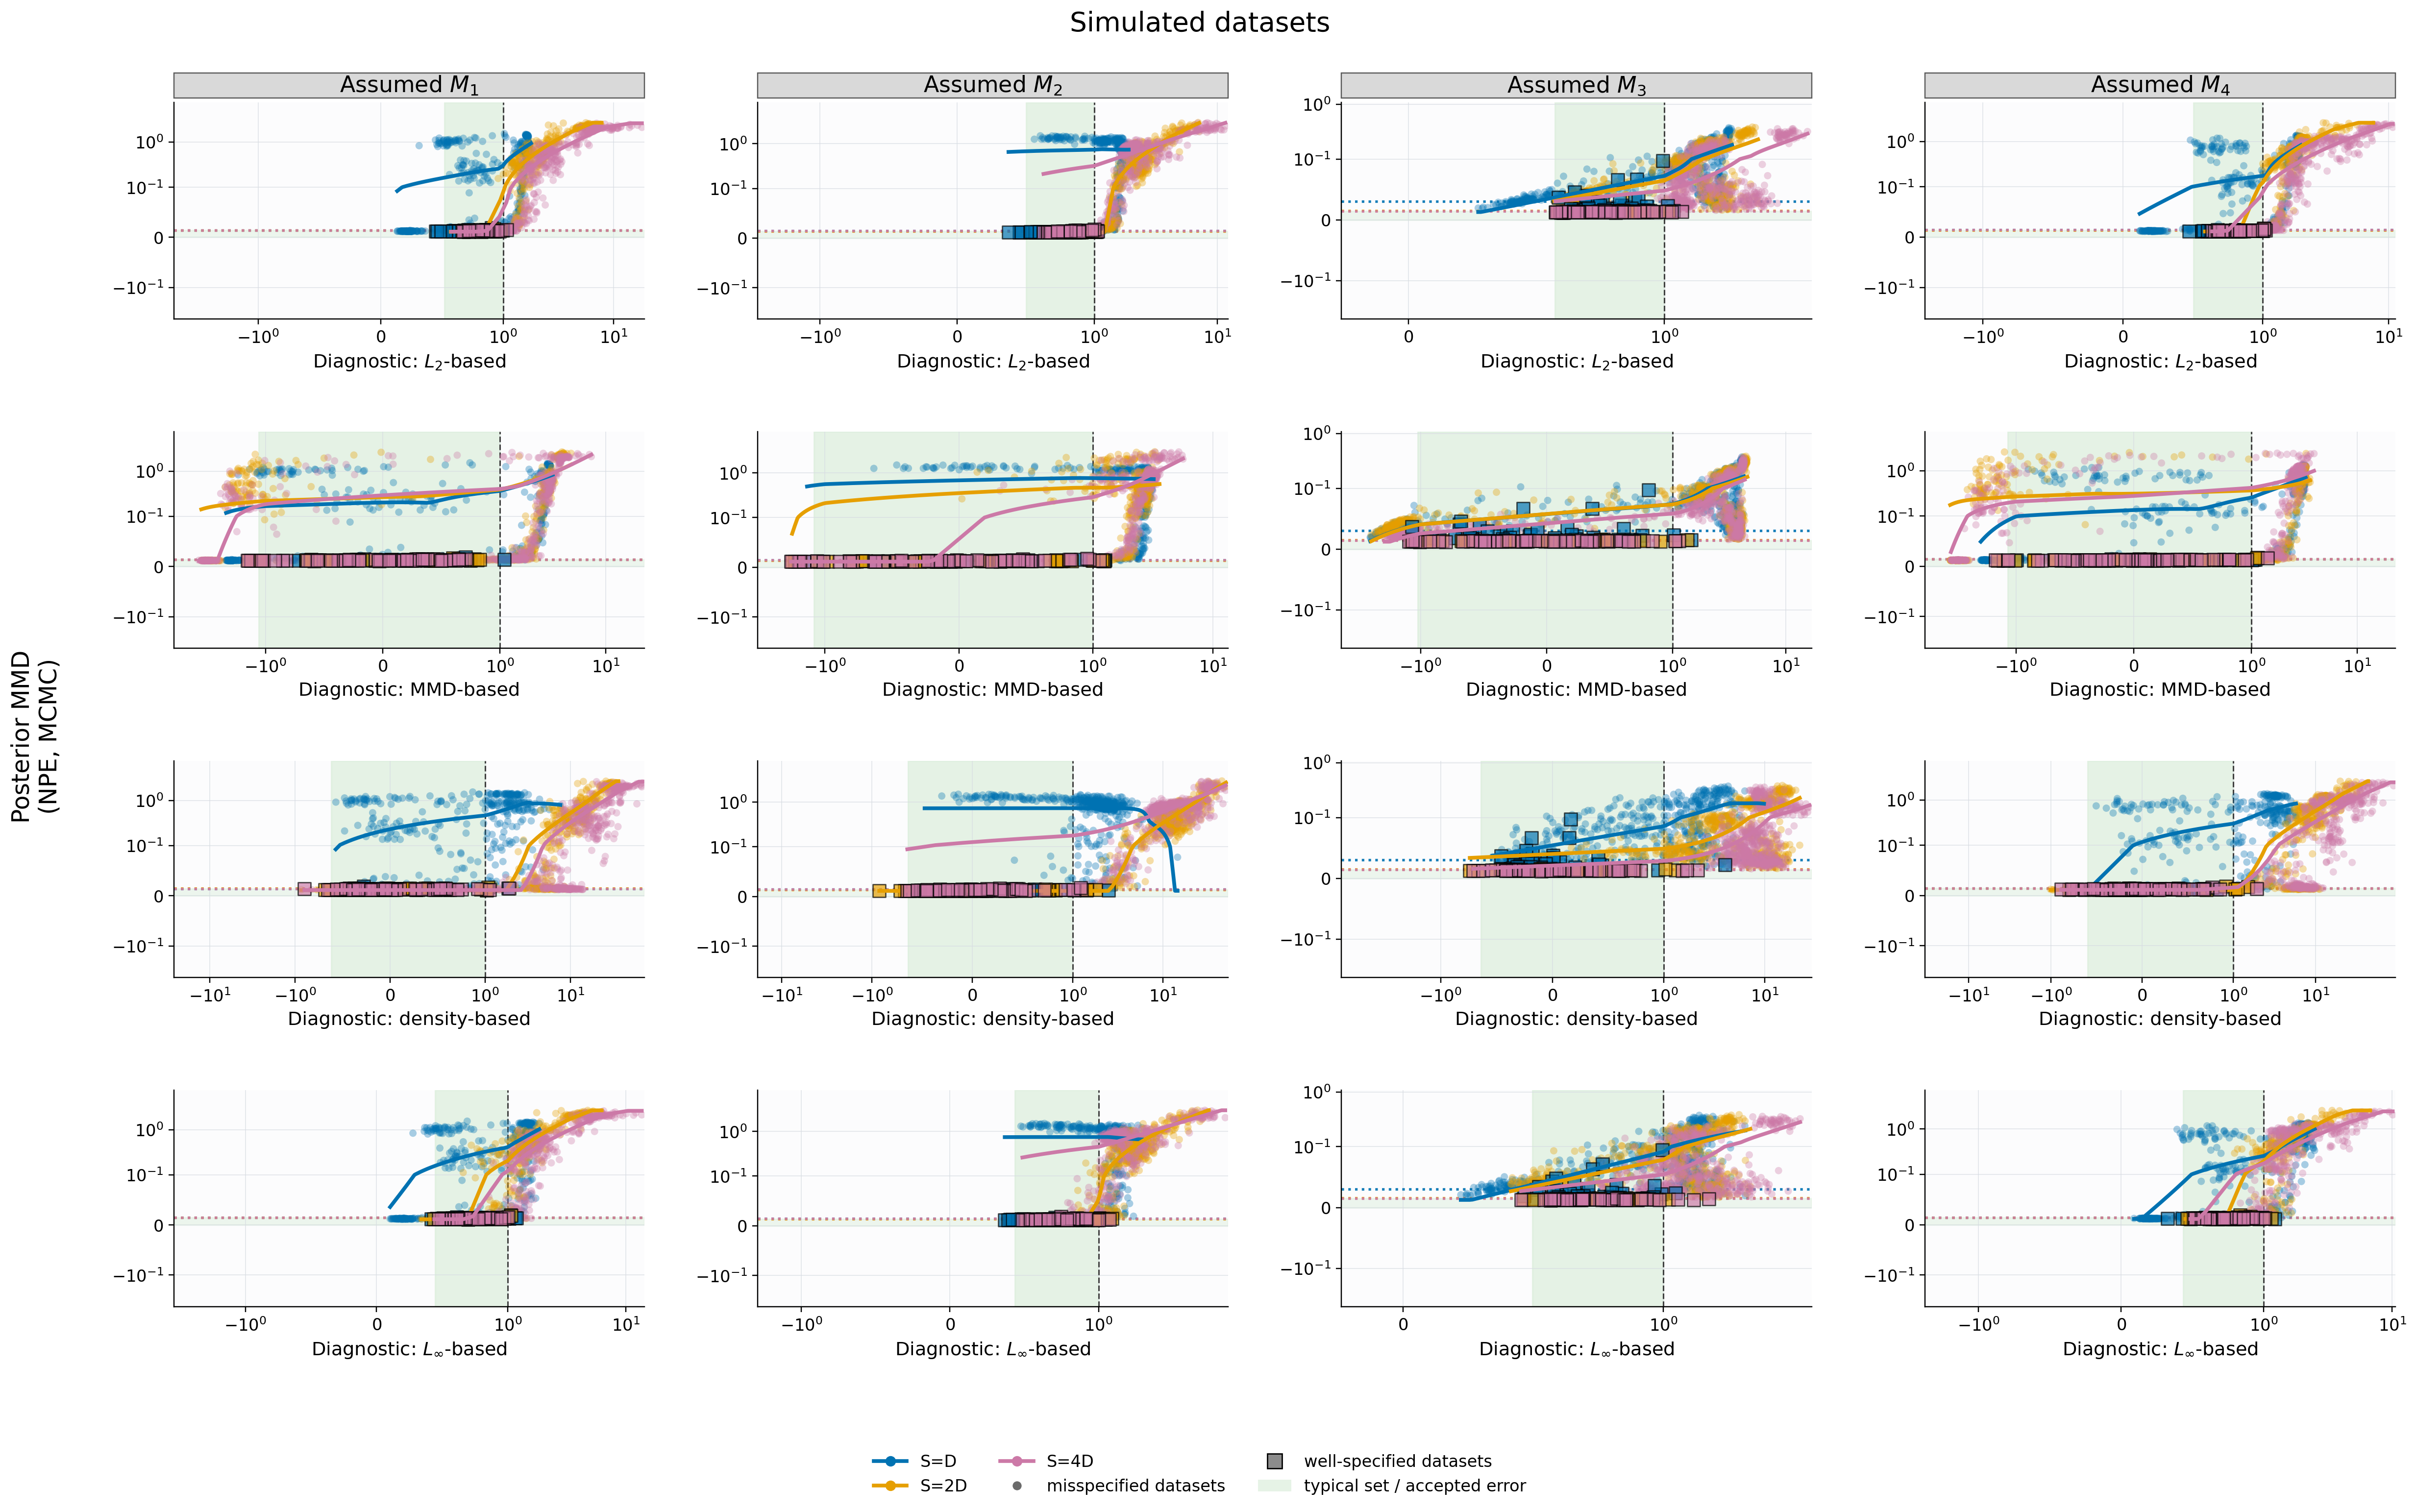

In [4]:
display(Image(filename=str(comparison["paths"]["posterior_mmd"])))

## Log10 marginal-likelihood error

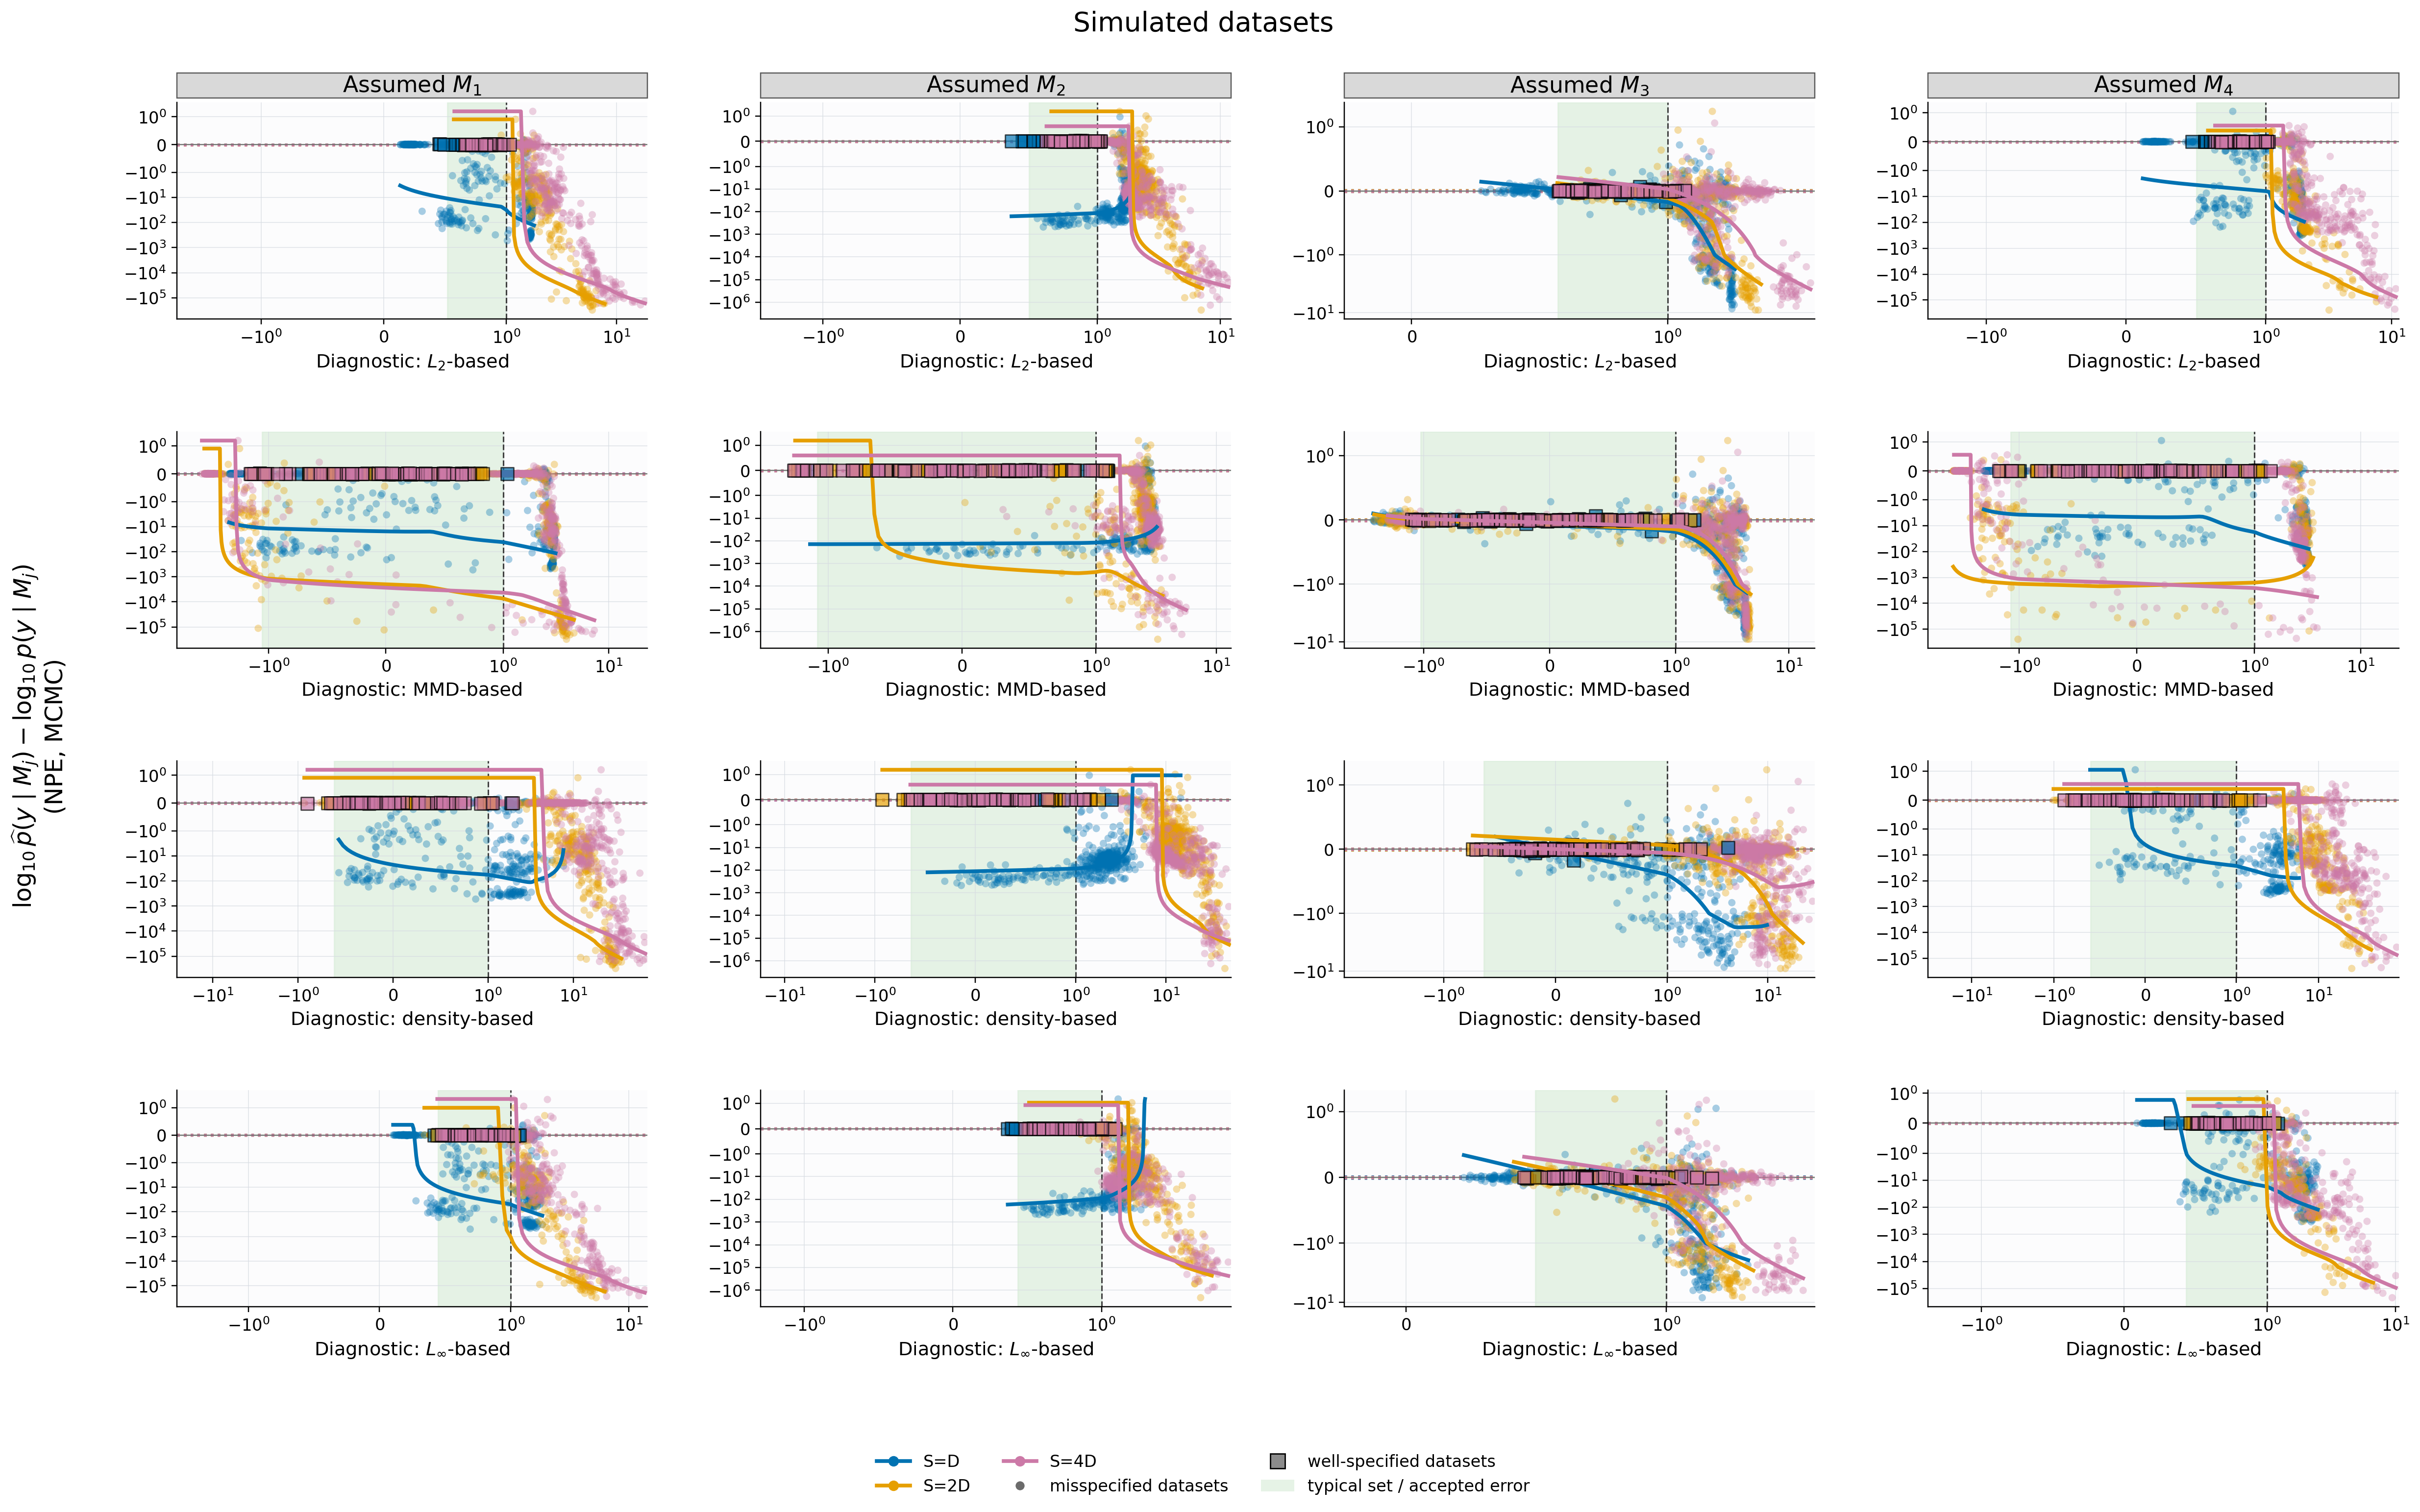

In [5]:
display(Image(filename=str(comparison["paths"]["log10_logml_error"])))

## PMP error

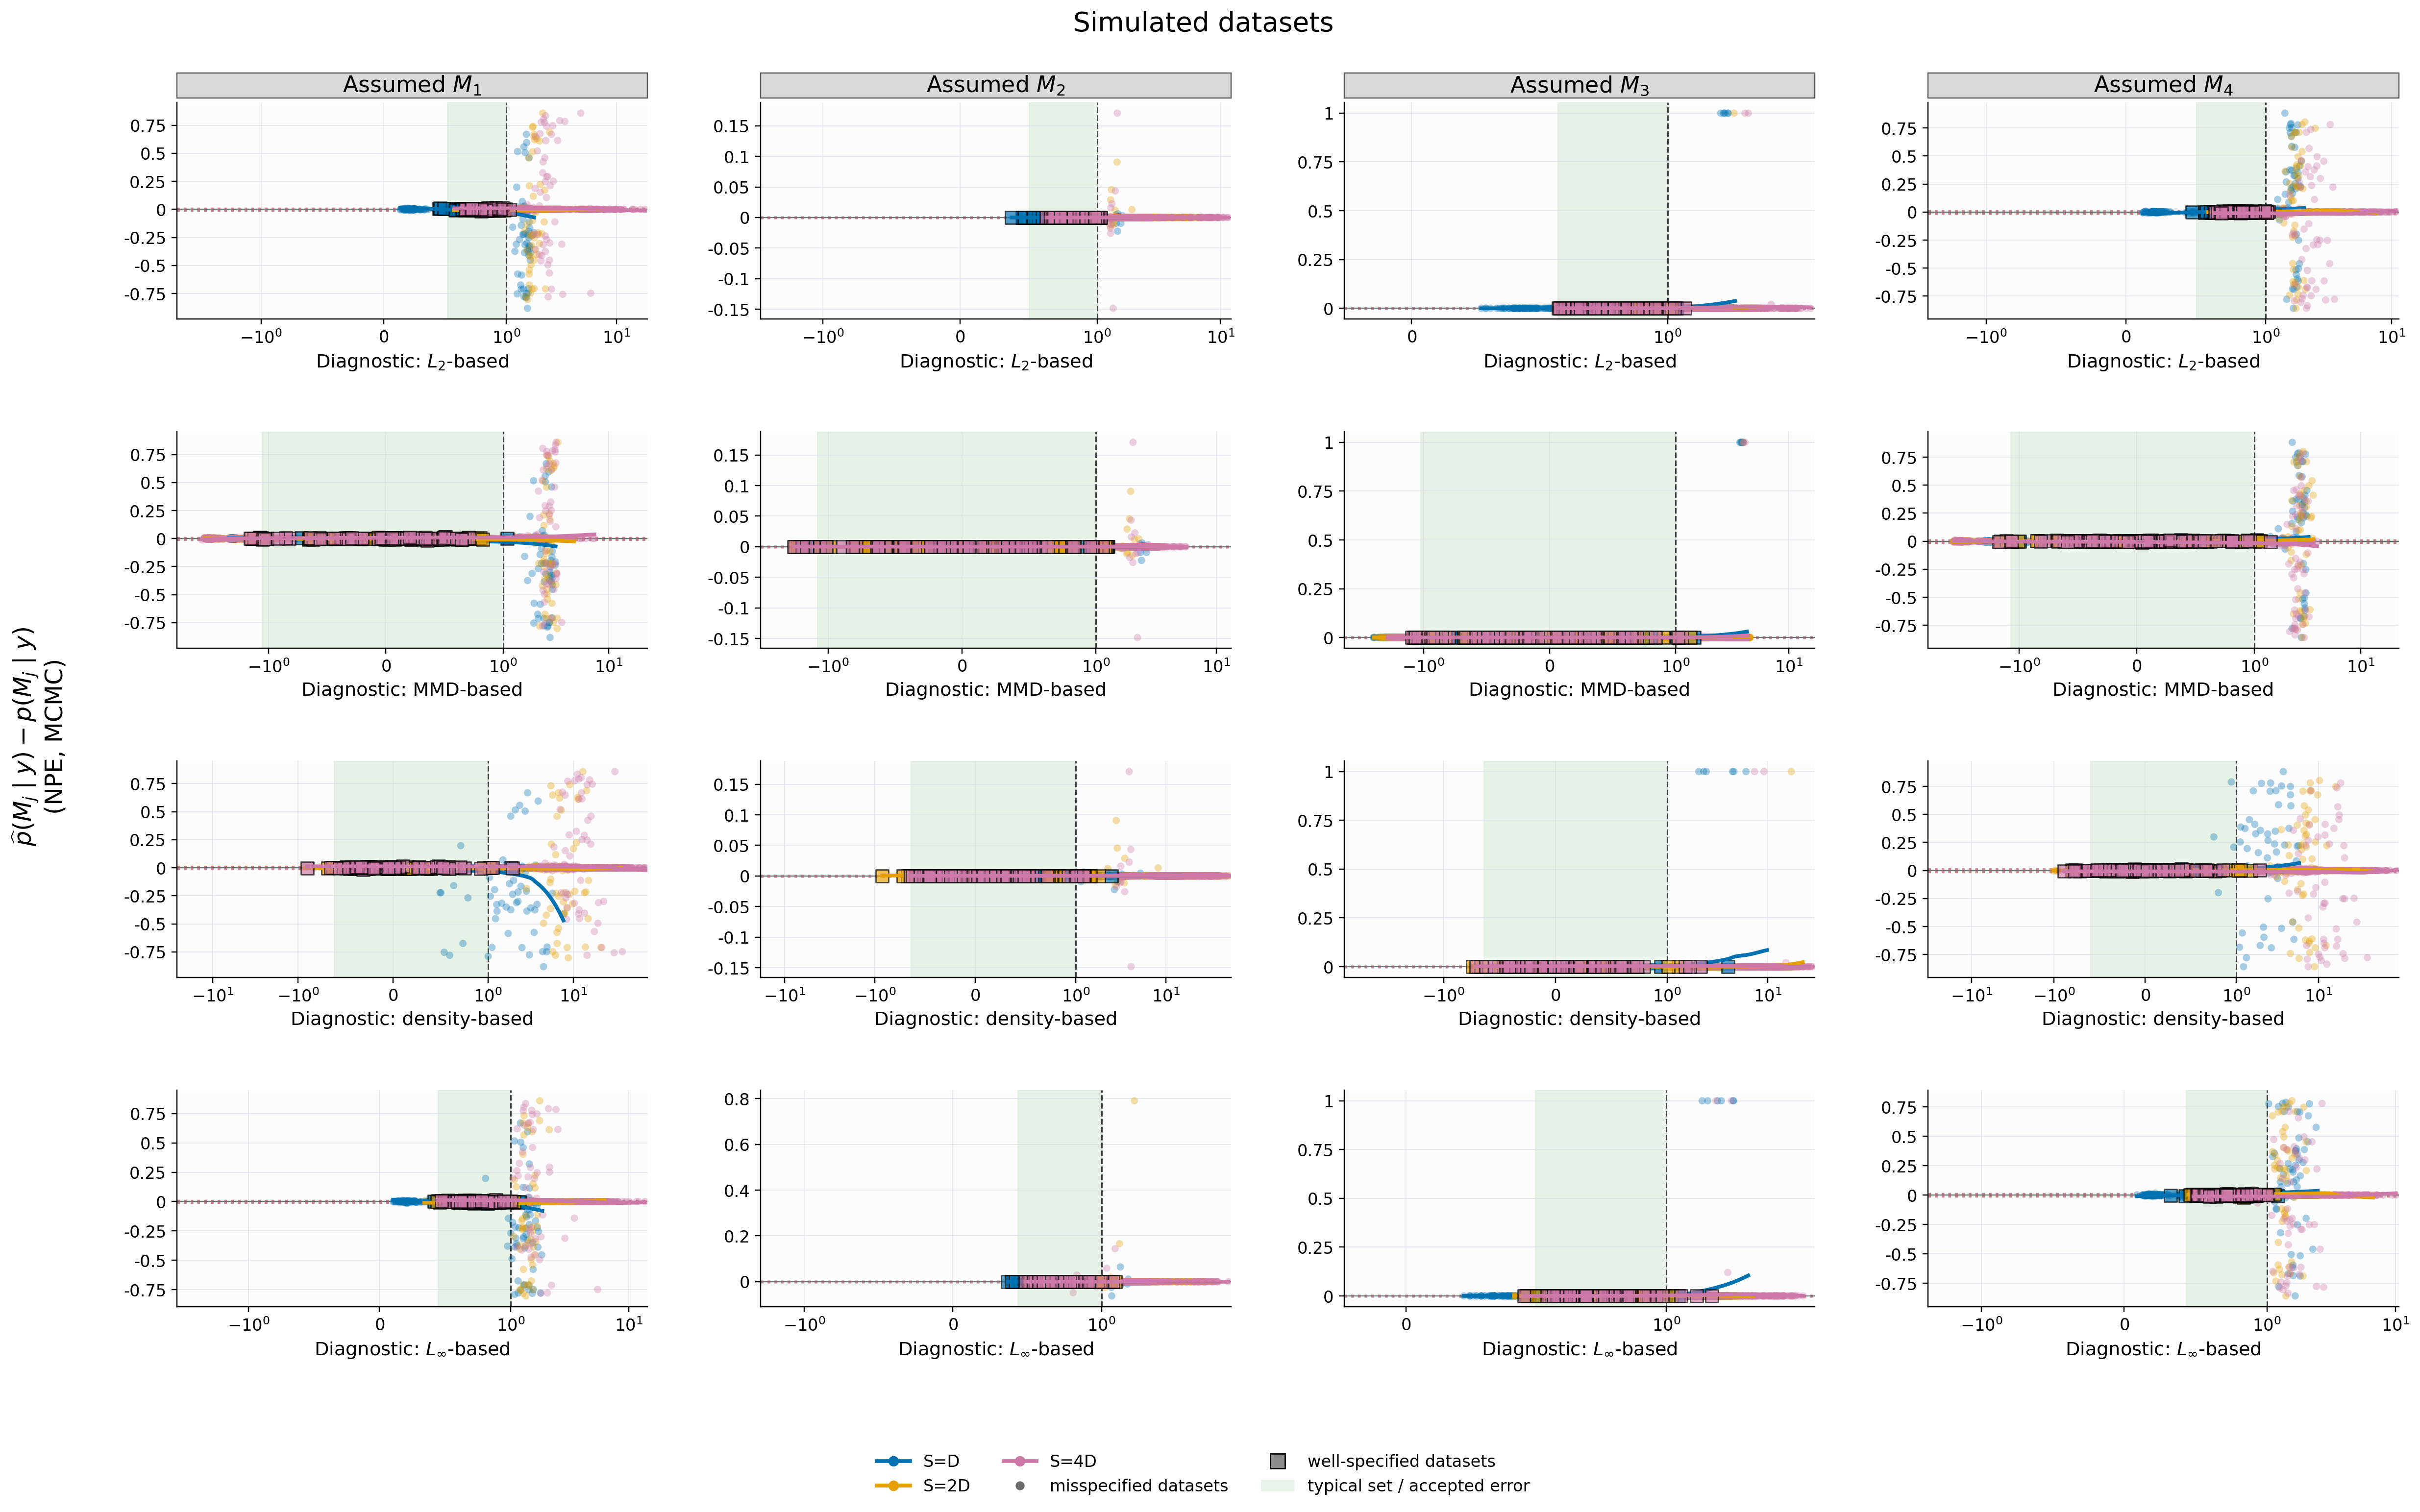

In [6]:
display(Image(filename=str(comparison["paths"]["pmp_error"])))

## Data coverage check

In [7]:
(
    comparison["data"]
    .groupby(["error_metric", "diagnostic", "summary"], observed=True)
    .size()
    .rename("n_rows")
    .unstack("summary")
)

summary                        S=D  S=2D  S=4D
error_metric      diagnostic                  
posterior_mmd     l2          2400  2400  2400
                  mmd         2400  2400  2400
                  density     2400  2400  2400
                  linf        2400  2400  2400
log10_logml_error l2          2400  2400  2400
                  mmd         2400  2400  2400
                  density     2400  2400  2400
                  linf        2400  2400  2400
pmp_error         l2          2400  2400  2400
                  mmd         2400  2400  2400
                  density     2400  2400  2400
                  linf        2400  2400  2400